# Learning the Data Distribution of Handwritten Digits using a Variational Autoencoder

A simple VAE on MNIST and Fashion-MNIST. The experiments analyze Gaussian latent distributions, latent-space dimensionality, reconstruction quality, and random sample generation.

In [1]:
# Setup

import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [2]:
# Datasets: Load MNIST and Fashion-MNIST

transform = transforms.ToTensor()
batch_size = 128

# MNIST
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Fashion-MNIST
fashion_train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
fashion_test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

fashion_train_loader = DataLoader(fashion_train_dataset, batch_size=batch_size, shuffle=True)
fashion_test_loader = DataLoader(fashion_test_dataset, batch_size=batch_size,shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.1MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.1MB/s]


In [3]:
# VAE Model: Define functions

input_dim = 784
hidden_dim = 256

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=8):
        super().__init__()

        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU())
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, input_dim), nn.Sigmoid())

    def encode(self, x):
        hidden = self.encoder(x)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        epsilon = torch.randn_like(std)
        return mu+epsilon*std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mu, logvar

def vae_loss(reconstructed, original, mu, logvar):
    recon_loss = F.binary_cross_entropy(reconstructed, original, reduction="sum")
    kl_loss = -0.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
    total_loss = recon_loss+kl_loss

    return total_loss, recon_loss, kl_loss


def train_model(model, loader, optimizer, num_epochs, device):
    history = {"total": [], "recon": [], "kl": []}

    for epoch in range(num_epochs):
        model.train()

        total_sum = 0
        recon_sum = 0
        kl_sum = 0

        for images, _ in loader:
            images = images.to(device)
            images = images.view(images.size(0), -1)

            optimizer.zero_grad()

            reconstructed, mu, logvar = model(images)

            total_loss, recon_loss, kl_loss = vae_loss(reconstructed, images, mu, logvar)

            total_loss.backward()
            optimizer.step()

            total_sum += total_loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()

        dataset_size = len(loader.dataset)

        history["total"].append(total_sum/dataset_size)
        history["recon"].append(recon_sum/dataset_size)
        history["kl"].append(kl_sum/dataset_size)

    return model, history

def evaluate_model(model, loader, device):

    model.eval()

    total_sum = 0
    recon_sum = 0
    kl_sum = 0

    with torch.no_grad():
        for images, _ in loader:

            images = images.to(device)
            images = images.view(images.size(0), -1)

            reconstructed, mu, logvar = model(images)

            total_loss, recon_loss, kl_loss = vae_loss(reconstructed, images, mu, logvar)

            total_sum += total_loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()

    dataset_size = len(loader.dataset)

    return {"total_loss": total_sum/dataset_size, "recon_loss": recon_sum/dataset_size,"kl_loss": kl_sum/dataset_size}

In [4]:
# MNIST Training: Train with latent dimensions 2, 8, and 16 & Evaluation

latent_dims = [2, 8, 16]
num_epochs = 10

mnist_models = {}
mnist_results = {}
mnist_histories = {}

for dim in latent_dims:

    print(f"Training MNIST VAE with latent_dim = {dim}")

    current_model = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=dim).to(device)

    optimizer = torch.optim.Adam(current_model.parameters(), lr=1e-3)

    current_model, history = train_model(current_model, train_loader, optimizer, num_epochs, device)

    mnist_models[dim] = current_model
    mnist_histories[dim] = history
    mnist_results[dim] = evaluate_model(current_model, test_loader, device)

    print(mnist_results[dim])

Training MNIST VAE with latent_dim = 2
{'total_loss': 155.37625217285157, 'recon_loss': 149.6532046875, 'kl_loss': 5.723046993255616}
Training MNIST VAE with latent_dim = 8
{'total_loss': 116.03867454833984, 'recon_loss': 100.20407839355468, 'kl_loss': 15.834596154785157}
Training MNIST VAE with latent_dim = 16
{'total_loss': 107.85721970214844, 'recon_loss': 85.10753051757813, 'kl_loss': 22.74968876953125}


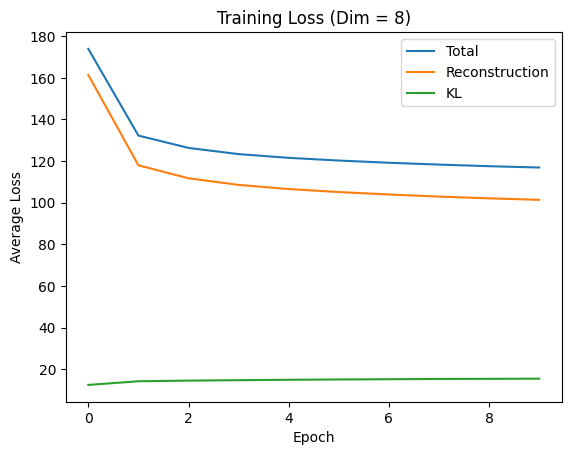

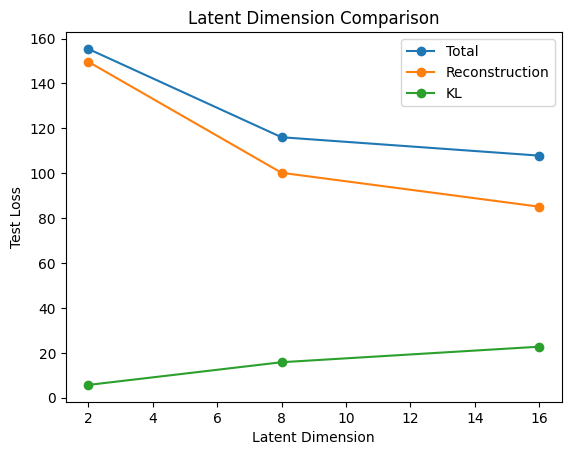

Dim 2 | Total: 155.3763 | Recon: 149.6532 | KL: 5.7230
Dim 8 | Total: 116.0387 | Recon: 100.2041 | KL: 15.8346
Dim 16 | Total: 107.8572 | Recon: 85.1075 | KL: 22.7497


In [5]:
# MNIST Results

plt.plot(mnist_histories[8]["total"], label="Total")
plt.plot(mnist_histories[8]["recon"], label="Reconstruction")
plt.plot(mnist_histories[8]["kl"], label="KL")

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss (Dim = 8)")
plt.legend()
plt.show()


# Test loss comparison
recon_losses = [mnist_results[d]["recon_loss"] for d in latent_dims]
kl_losses = [mnist_results[d]["kl_loss"] for d in latent_dims]
total_losses = [mnist_results[d]["total_loss"] for d in latent_dims]

plt.plot(latent_dims, total_losses, marker="o", label="Total")
plt.plot(latent_dims, recon_losses, marker="o", label="Reconstruction")
plt.plot(latent_dims, kl_losses, marker="o", label="KL")

plt.xlabel("Latent Dimension")
plt.ylabel("Test Loss")
plt.title("Latent Dimension Comparison")
plt.legend()
plt.show()

for dim in latent_dims:
    print(
        f"Dim {dim} | "
        f"Total: {mnist_results[dim]['total_loss']:.4f} | "
        f"Recon: {mnist_results[dim]['recon_loss']:.4f} | "
        f"KL: {mnist_results[dim]['kl_loss']:.4f}"
    )

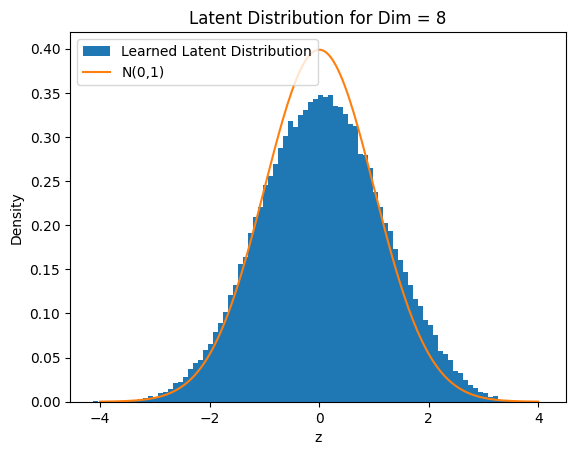

Dim 1: mean=0.060, std=1.186
Dim 2: mean=0.103, std=1.083
Dim 3: mean=0.142, std=1.095
Dim 4: mean=-0.156, std=1.052
Dim 5: mean=0.103, std=1.176
Dim 6: mean=-0.032, std=1.151
Dim 7: mean=0.189, std=1.079
Dim 8: mean=0.067, std=1.069


In [6]:
## Gaussian Distribution and compare the dim=8 latent distribution

model_8 = mnist_models[8]
model_8.eval()

all_z = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device).view(images.size(0), -1)

        mu, logvar = model_8.encode(images)
        z = model_8.reparameterize(mu, logvar)
        all_z.append(z.cpu())

all_z = torch.cat(all_z)

x = np.linspace(-4, 4, 200)
gaussian = (1/np.sqrt(2*np.pi))*np.exp(-0.5*x**2)

plt.hist(all_z.flatten().numpy(), bins=90, density=True, label="Learned Latent Distribution")
plt.plot(x, gaussian, label="N(0,1)")

plt.xlabel("z")
plt.ylabel("Density")
plt.title("Latent Distribution for Dim = 8")
plt.legend()
plt.show()

# Mean and standard deviation of each latent dimension
for i in range(8):
    print(
        f"Dim {i + 1}: "
        f"mean={all_z[:, i].mean():.3f}, "
        f"std={all_z[:, i].std():.3f}"
    )

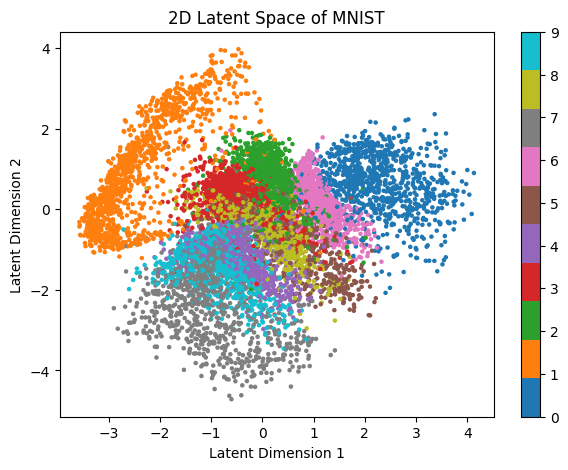

In [7]:
# 2D Latent Space Analysis

model_2 = mnist_models[2]
model_2.eval()

all_mu = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device).view(images.size(0), -1)

        mu, _ = model_2.encode(images)

        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu = torch.cat(all_mu)
all_labels = torch.cat(all_labels)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap="tab10", s=5)

plt.colorbar(scatter, ticks=range(10))
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space of MNIST")
plt.show()

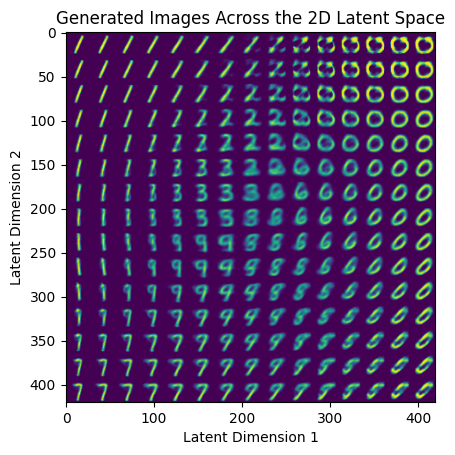

In [8]:
# Generate images across different positions in the 2D latent space.

grid_size = 15

grid_x = torch.linspace(-3, 3, grid_size)
grid_y = torch.linspace(3, -3, grid_size)

canvas = np.zeros((28 * grid_size, 28 * grid_size))

with torch.no_grad():
    for i, y in enumerate(grid_y):
        for j, x in enumerate(grid_x):

            z = torch.tensor([[x, y]], dtype=torch.float32, device=device)
            image = model_2.decode(z)
            image = image.view(28, 28).cpu().numpy()
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = image

plt.imshow(canvas)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Generated Images Across the 2D Latent Space")
plt.show()

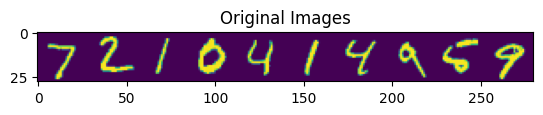

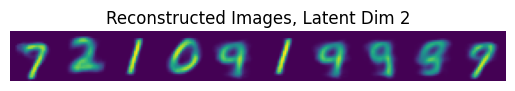

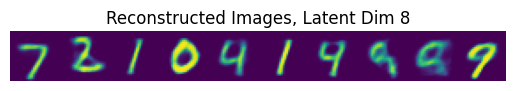

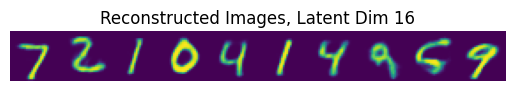

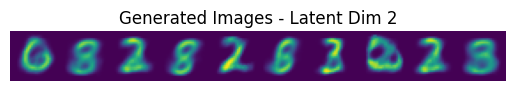

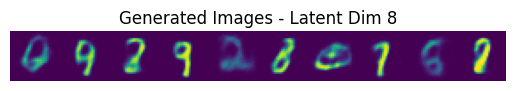

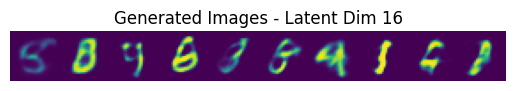

In [9]:
# MNIST Visual Comparison

num_images = 10

test_images, _ = next(iter(test_loader))
test_images = test_images[:num_images].to(device)
flat_images = test_images.view(num_images, -1)

original_strip = torch.cat([test_images[i].cpu() for i in range(num_images)], dim=2)

plt.imshow(original_strip.squeeze())
plt.title("Original Images")
plt.show()


# Reconstruction comparison
for dim in latent_dims:
    model = mnist_models[dim]
    model.eval()

    with torch.no_grad():
        mu, _ = model.encode(flat_images)
        reconstructed = model.decode(mu)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

    recon_strip = torch.cat([reconstructed[i].cpu() for i in range(num_images)], dim=2)

    plt.imshow(recon_strip.squeeze())
    plt.title(f"Reconstructed Images, Latent Dim {dim}")
    plt.axis("off")
    plt.show()


# Generated sample comparison
for dim in latent_dims:
    model = mnist_models[dim]
    model.eval()

    with torch.no_grad():
        z = torch.randn(num_images, dim, device=device)
        generated = model.decode(z)
        generated = generated.view(-1, 1, 28, 28)

    generated_strip = torch.cat([generated[i].cpu() for i in range(num_images)], dim=2)

    plt.imshow(generated_strip.squeeze())
    plt.title(f"Generated Images - Latent Dim {dim}")
    plt.axis("off")
    plt.show()

In [10]:
# Fashion-MNIST Training with latent dimensions 2, 8, and 16 & Evaluation

fashion_models = {}
fashion_results = {}
fashion_histories = {}

for dim in latent_dims:

    print(f"Training Fashion-MNIST VAE with latent_dim = {dim}")

    current_model = VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=dim).to(device)

    optimizer = torch.optim.Adam( current_model.parameters(), lr=1e-3)

    current_model, history = train_model(current_model, fashion_train_loader, optimizer, num_epochs, device)

    fashion_models[dim] = current_model
    fashion_histories[dim] = history
    fashion_results[dim] = evaluate_model( current_model, fashion_test_loader, device)

    print(fashion_results[dim])

Training Fashion-MNIST VAE with latent_dim = 2
{'total_loss': 264.72930935058594, 'recon_loss': 257.92375583496096, 'kl_loss': 6.805553259277343}
Training Fashion-MNIST VAE with latent_dim = 8
{'total_loss': 245.363192578125, 'recon_loss': 231.5190483642578, 'kl_loss': 13.844144123840332}
Training Fashion-MNIST VAE with latent_dim = 16
{'total_loss': 245.44780224609374, 'recon_loss': 230.1270650390625, 'kl_loss': 15.320737939453124}


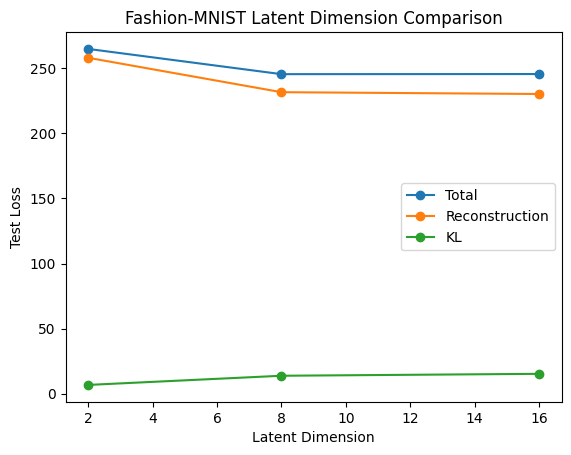

Dim 2 | Total: 264.7293 | Recon: 257.9238 | KL: 6.8056
Dim 8 | Total: 245.3632 | Recon: 231.5190 | KL: 13.8441
Dim 16 | Total: 245.4478 | Recon: 230.1271 | KL: 15.3207


In [11]:
# 9. Fashion-MNIST: Compare reconstruction, KL, and total test losses

fashion_recon_losses = [fashion_results[d]["recon_loss"] for d in latent_dims]
fashion_kl_losses = [fashion_results[d]["kl_loss"] for d in latent_dims]
fashion_total_losses = [fashion_results[d]["total_loss"] for d in latent_dims]

plt.plot(latent_dims, fashion_total_losses, marker="o", label="Total")
plt.plot(latent_dims, fashion_recon_losses, marker="o", label="Reconstruction")
plt.plot(latent_dims, fashion_kl_losses, marker="o", label="KL")

plt.xlabel("Latent Dimension")
plt.ylabel("Test Loss")
plt.title("Fashion-MNIST Latent Dimension Comparison")
plt.legend()
plt.show()

for dim in latent_dims:
    print(
        f"Dim {dim} | "
        f"Total: {fashion_results[dim]['total_loss']:.4f} | "
        f"Recon: {fashion_results[dim]['recon_loss']:.4f} | "
        f"KL: {fashion_results[dim]['kl_loss']:.4f}"
    )

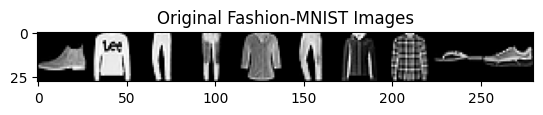

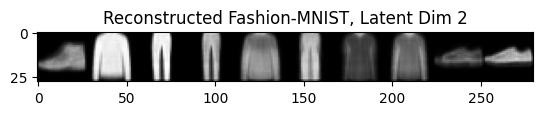

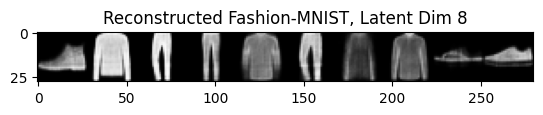

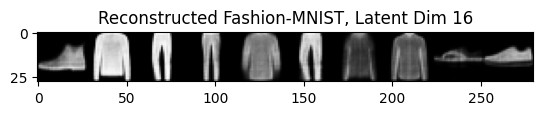

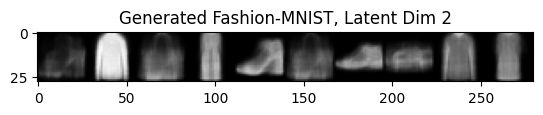

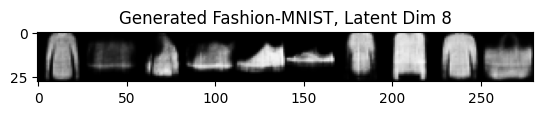

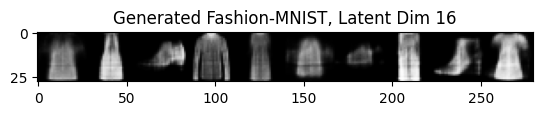

In [12]:
# Fashion-MNIST Visual Comparison

num_images = 10

fashion_images, _ = next(iter(fashion_test_loader))
fashion_images = fashion_images[:num_images].to(device)
flat_fashion = fashion_images.view(num_images, -1)

original_strip = torch.cat([fashion_images[i].cpu() for i in range(num_images)], dim=2)

plt.imshow(original_strip.squeeze(),cmap="gray")
plt.title("Original Fashion-MNIST Images")
plt.show()


for dim in latent_dims:

    model = fashion_models[dim]
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(flat_fashion)
        reconstructed = model.decode(mu)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

    recon_strip = torch.cat([reconstructed[i].cpu() for i in range(num_images)], dim=2)

    plt.imshow(recon_strip.squeeze(), cmap="gray")
    plt.title(f"Reconstructed Fashion-MNIST, Latent Dim {dim}")
    plt.show()

for dim in latent_dims:

    model = fashion_models[dim]
    model.eval()

    with torch.no_grad():
        z = torch.randn(num_images, dim, device=device)
        generated = model.decode(z)
        generated = generated.view(-1, 1, 28, 28)

    generated_strip = torch.cat([generated[i].cpu() for i in range(num_images)], dim=2)

    plt.imshow(generated_strip.squeeze(), cmap="gray")
    plt.title(f"Generated Fashion-MNIST, Latent Dim {dim}")
    plt.show()